In [17]:
# Configuración inicial del entorno
import sys
import os
from pathlib import Path

print("🔄 Configurando entorno...")

# Obtener el directorio raíz del proyecto
notebook_dir = Path().resolve()
if notebook_dir.name == "notebooks":
    project_root = notebook_dir.parent
else:
    # Buscar el directorio con pyproject.toml
    project_root = notebook_dir
    while project_root != project_root.parent:
        if (project_root / "pyproject.toml").exists():
            break
        project_root = project_root.parent

print(f"📁 Directorio raíz: {project_root}")

# Cambiar al directorio raíz
os.chdir(project_root)
print(f"✓ Directorio de trabajo: {os.getcwd()}")

# Agregar al path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Verificar pyproject.toml
if (project_root / "pyproject.toml").exists():
    print("✓ pyproject.toml encontrado")
else:
    raise FileNotFoundError(f"pyproject.toml no encontrado en {project_root}")

print("✅ Configuración completada\n")


🔄 Configurando entorno...
📁 Directorio raíz: C:\Users\PC RST\Documents\GitHub\ML_ClashRoyale
✓ Directorio de trabajo: C:\Users\PC RST\Documents\GitHub\ML_ClashRoyale
✓ pyproject.toml encontrado
✅ Configuración completada



# 📊 Fase 5: Aprendizaje No Supervisado

Este notebook documenta la **fase de Aprendizaje No Supervisado** del proyecto ML Clash Royale.
Incluye análisis de clustering, reducción de dimensionalidad, detección de anomalías y reglas de asociación.

## 1. Introducción

El aprendizaje no supervisado nos permite:
- **Clustering**: Identificar grupos naturales de batallas similares
- **Reducción de Dimensionalidad**: Visualizar y simplificar datos de alta dimensionalidad
- **Detección de Anomalías**: Encontrar batallas o patrones inusuales
- **Reglas de Asociación**: Descubrir combinaciones frecuentes de cartas


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

# Configuración de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("✅ Librerías importadas exitosamente")


✅ Librerías importadas exitosamente


## 2. Cargar Datos y Resultados

### 2.1. Datos de Entrenamiento


In [19]:
# Cargar datos de entrenamiento desde Kedro
# Nota: Esta celda requiere que la celda de configuración inicial se haya ejecutado

try:
    # Verificar que project_root está definido
    if 'project_root' not in globals():
        raise NameError("project_root no está definido. Ejecuta primero la celda de configuración inicial.")
    
    print("🔄 Cargando datos desde Kedro...")
    
    # Importar y configurar Kedro
    from kedro.framework.session import KedroSession
    from kedro.framework.startup import bootstrap_project
    
    # Bootstrap del proyecto
    metadata = bootstrap_project(project_root)
    
    # Crear sesión de Kedro
    session = KedroSession.create(project_path=project_root)
    context = session.load_context()
    catalog = context.catalog
    
    # Intentar cargar datos de entrenamiento
    try:
        train_data = catalog.load("train_data")
        print(f"✅ Datos de entrenamiento cargados: {train_data.shape}")
        print(f"   Columnas: {len(train_data.columns)} features")
    except Exception as e:
        print(f"⚠ train_data no disponible en el catálogo: {str(e)[:80]}")
        # Intentar cargar directamente desde archivo como alternativa
        train_data_path = project_root / "data" / "05_model_input" / "train_data.csv"
        if train_data_path.exists():
            train_data = pd.read_csv(train_data_path)
            print(f"✅ Datos cargados desde archivo: {train_data.shape}")
        else:
            print(f"❌ Archivo no encontrado: {train_data_path}")
            train_data = None
            print("💡 Ejecuta primero: kedro run --pipeline=feature_engineering")
    
except NameError as e:
    print(f"❌ Error: {e}")
    print("💡 Ejecuta primero la celda de configuración inicial")
    train_data = None
except Exception as e:
    print(f"❌ Error al cargar datos: {e}")
    print("💡 Posibles soluciones:")
    print("   1. Verifica que ejecutaste la celda de configuración inicial")
    print("   2. Ejecuta: kedro run --pipeline=feature_engineering")
    import traceback
    traceback.print_exc()
    train_data = None


🔄 Cargando datos desde Kedro...


[11/28/25 16:07:43] WARNING  c:\Users\PC                                                            warnings.py:112
                             RST\Documents\GitHub\ML_ClashRoyale\venv\Lib\site-packages\kedro\frame                
                             work\project\__init__.py:350: UserWarning: The                                        
                             'proyecto_ml_clashroyale.pipelines.nodes' module does not expose a                    
                             'create_pipeline' function, so no pipelines defined therein will be                   
                             returned by 'find_pipelines'.                                                         
                               warnings.warn(                                                                      
                                                                                                                   

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving plugin.py:243
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/configuration/telemetry.html                         

[11/28/25 16:07:44] INFO     Loading data from train_data (CSVDataset)...                      data_catalog.py:1048

✅ Datos de entrenamiento cargados: (16032, 113)
   Columnas: 113 features


### 2.2. Cargar Métricas de Clustering


In [20]:
# Cargar métricas de clustering
# Nota: Esta celda requiere que la celda de configuración inicial se haya ejecutado

try:
    # Verificar que project_root está definido
    if 'project_root' not in globals():
        raise NameError("project_root no está definido. Ejecuta primero la celda de configuración inicial.")
    
    # Intentar cargar desde el catálogo de Kedro primero
    try:
        from kedro.framework.session import KedroSession
        from kedro.framework.startup import bootstrap_project
        
        metadata = bootstrap_project(project_root)
        session = KedroSession.create(project_path=project_root)
        context = session.load_context()
        catalog = context.catalog
        
        clustering_comparison = catalog.load("clustering_comparison")
        print("✅ Métricas de clustering cargadas desde catálogo")
    except Exception:
        # Si no está en el catálogo, intentar cargar desde archivo
        clustering_path = project_root / "data" / "08_reporting" / "clustering_comparison.json"
        if clustering_path.exists():
            with open(clustering_path, 'r') as f:
                clustering_comparison = json.load(f)
            print("✅ Métricas de clustering cargadas desde archivo")
        else:
            raise FileNotFoundError(f"Archivo no encontrado: {clustering_path}")
    
    # Mostrar métricas
    if clustering_comparison:
        print(f"  - K-Means: {clustering_comparison['kmeans']['silhouette_score']:.4f}")
        print(f"  - OPTICS: {clustering_comparison['optics']['silhouette_score']:.4f}")
        print(f"  - Hierarchical: {clustering_comparison['hierarchical']['silhouette_score']:.4f}")
    
except NameError as e:
    print(f"❌ Error: {e}")
    print("💡 Ejecuta primero la celda de configuración inicial")
    clustering_comparison = None
except FileNotFoundError as e:
    print(f"⚠ {e}")
    print("💡 Ejecuta primero: kedro run --pipeline=unsupervised_learning")
    clustering_comparison = None
except Exception as e:
    print(f"❌ Error al cargar métricas: {e}")
    print("💡 Ejecuta primero: kedro run --pipeline=unsupervised_learning")
    import traceback
    traceback.print_exc()
    clustering_comparison = None


                    WARNING  c:\Users\PC                                                            warnings.py:112
                             RST\Documents\GitHub\ML_ClashRoyale\venv\Lib\site-packages\kedro\frame                
                             work\project\__init__.py:350: UserWarning: The                                        
                             'proyecto_ml_clashroyale.pipelines.nodes' module does not expose a                    
                             'create_pipeline' function, so no pipelines defined therein will be                   
                             returned by 'find_pipelines'.                                                         
                               warnings.warn(                                                                      
                                                                                                                   

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving plugin.py:243
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/configuration/telemetry.html                         

[11/28/25 16:07:45] INFO     Loading data from clustering_comparison (JSONDataset)...          data_catalog.py:1048

✅ Métricas de clustering cargadas desde catálogo
  - K-Means: 0.0147
  - OPTICS: 0.3203
  - Hierarchical: 0.0097


## 3. Análisis de Clustering

### 3.1. Comparación de Métricas


In [21]:
if 'clustering_comparison' in locals():
    clustering_df = pd.DataFrame({
        'Algoritmo': ['K-Means', 'OPTICS', 'Hierarchical'],
        'Silhouette Score': [
            clustering_comparison['kmeans']['silhouette_score'],
            clustering_comparison['optics']['silhouette_score'],
            clustering_comparison['hierarchical']['silhouette_score']
        ],
        'Davies-Bouldin': [
            clustering_comparison['kmeans']['davies_bouldin_index'],
            clustering_comparison['optics']['davies_bouldin_index'],
            clustering_comparison['hierarchical']['davies_bouldin_index']
        ],
        'N Clusters': [
            clustering_comparison['kmeans']['n_clusters'],
            clustering_comparison['optics']['n_clusters'],
            clustering_comparison['hierarchical']['n_clusters']
        ]
    })
    print(clustering_df.to_string(index=False))


   Algoritmo  Silhouette Score  Davies-Bouldin  N Clusters
     K-Means          0.014721        6.231190           5
      OPTICS          0.320333        1.017730          58
Hierarchical          0.009672        7.225228           5


## 4. Análisis de Reducción de Dimensionalidad

### 4.1. PCA - Varianza Explicada


### 4.2. Análisis de Detección de Anomalías


In [ ]:
# Cargar resultados de detección de anomalías
# Nota: Esta celda requiere que la celda de configuración inicial se haya ejecutado

try:
    if 'project_root' not in globals():
        raise NameError("project_root no está definido. Ejecuta primero la celda de configuración inicial.")
    
    # Intentar cargar desde Kedro primero
    try:
        from kedro.framework.session import KedroSession
        from kedro.framework.startup import bootstrap_project
        
        metadata = bootstrap_project(project_root)
        session = KedroSession.create(project_path=project_root)
        context = session.load_context()
        catalog = context.catalog
        
        # Intentar cargar comparación de anomalías
        try:
            anomaly_comparison = catalog.load("anomaly_detection_comparison")
            print("✅ Resultados de detección de anomalías cargados desde catálogo")
            
            print("\n📊 Comparación de Algoritmos de Detección de Anomalías:")
            print("=" * 60)
            for algo, metrics in anomaly_comparison.items():
                if algo != 'best_model':
                    print(f"\n{algo.upper()}:")
                    print(f"  - Anomalías detectadas: {metrics.get('n_anomalies', 'N/A')}")
                    print(f"  - Porcentaje de anomalías: {metrics.get('anomaly_percentage', 'N/A'):.2f}%")
                    if 'silhouette_score' in metrics:
                        print(f"  - Silhouette Score: {metrics['silhouette_score']:.4f}")
        except Exception as e:
            print(f"⚠ anomaly_detection_comparison no disponible: {str(e)[:80]}")
            anomaly_comparison = None
    except Exception:
        # Fallback a archivo
        anomaly_path = project_root / "data" / "08_reporting" / "anomaly_detection_comparison.json"
        if anomaly_path.exists():
            with open(anomaly_path, 'r') as f:
                anomaly_comparison = json.load(f)
            print("✅ Resultados de detección de anomalías cargados desde archivo")
        else:
            print("⚠ Análisis de anomalías no disponible")
            print("💡 Ejecuta primero: kedro run --pipeline=anomaly_detection")
            anomaly_comparison = None
    
except NameError as e:
    print(f"❌ Error: {e}")
    print("💡 Ejecuta primero la celda de configuración inicial")
    anomaly_comparison = None
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()
    anomaly_comparison = None


### 4.3. Análisis de Reglas de Asociación


In [ ]:
# Cargar resultados de reglas de asociación
# Nota: Esta celda requiere que la celda de configuración inicial se haya ejecutado

try:
    if 'project_root' not in globals():
        raise NameError("project_root no está definido. Ejecuta primero la celda de configuración inicial.")
    
    # Intentar cargar desde Kedro primero
    try:
        from kedro.framework.session import KedroSession
        from kedro.framework.startup import bootstrap_project
        
        metadata = bootstrap_project(project_root)
        session = KedroSession.create(project_path=project_root)
        context = session.load_context()
        catalog = context.catalog
        
        # Intentar cargar reglas de asociación
        try:
            apriori_rules = catalog.load("apriori_rules")
            fpgrowth_rules = catalog.load("fpgrowth_rules")
            association_comparison = catalog.load("association_rules_comparison")
            
            print("✅ Reglas de asociación cargadas desde catálogo")
            
            print("\n📊 Resumen de Reglas de Asociación:")
            print("=" * 60)
            
            if association_comparison:
                print(f"\nApriori:")
                print(f"  - Total de reglas: {association_comparison.get('apriori', {}).get('total_rules', 'N/A')}")
                print(f"  - Reglas con lift > 1.0: {association_comparison.get('apriori', {}).get('rules_high_lift', 'N/A')}")
                
                print(f"\nFP-Growth:")
                print(f"  - Total de reglas: {association_comparison.get('fpgrowth', {}).get('total_rules', 'N/A')}")
                print(f"  - Reglas con lift > 1.0: {association_comparison.get('fpgrowth', {}).get('rules_high_lift', 'N/A')}")
            
            # Mostrar top reglas si están disponibles
            if apriori_rules is not None and len(apriori_rules) > 0:
                print(f"\n🔝 Top 5 Reglas Apriori (por Lift):")
                top_apriori = apriori_rules.nlargest(5, 'lift') if hasattr(apriori_rules, 'nlargest') else apriori_rules[:5]
                for idx, rule in enumerate(top_apriori.iterrows() if hasattr(top_apriori, 'iterrows') else top_apriori, 1):
                    if hasattr(rule, '__getitem__'):
                        print(f"  {idx}. {rule.get('antecedents', 'N/A')} -> {rule.get('consequents', 'N/A')}")
                        print(f"     Support: {rule.get('support', 'N/A'):.4f}, Confidence: {rule.get('confidence', 'N/A'):.4f}, Lift: {rule.get('lift', 'N/A'):.4f}")
            
        except Exception as e:
            print(f"⚠ Reglas de asociación no disponibles: {str(e)[:80]}")
            print("💡 Ejecuta primero: kedro run --pipeline=association_rules")
            apriori_rules = None
            fpgrowth_rules = None
            association_comparison = None
    except Exception:
        # Fallback a archivo
        association_path = project_root / "data" / "08_reporting" / "association_rules_comparison.json"
        if association_path.exists():
            with open(association_path, 'r') as f:
                association_comparison = json.load(f)
            print("✅ Reglas de asociación cargadas desde archivo")
        else:
            print("⚠ Análisis de reglas de asociación no disponible")
            print("💡 Ejecuta primero: kedro run --pipeline=association_rules")
            association_comparison = None
    
except NameError as e:
    print(f"❌ Error: {e}")
    print("💡 Ejecuta primero la celda de configuración inicial")
    association_comparison = None
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()
    association_comparison = None


                    WARNING  c:\Users\PC                                                            warnings.py:112
                             RST\Documents\GitHub\ML_ClashRoyale\venv\Lib\site-packages\kedro\frame                
                             work\project\__init__.py:350: UserWarning: The                                        
                             'proyecto_ml_clashroyale.pipelines.nodes' module does not expose a                    
                             'create_pipeline' function, so no pipelines defined therein will be                   
                             returned by 'find_pipelines'.                                                         
                               warnings.warn(                                                                      
                                                                                                                   

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving plugin.py:243
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/configuration/telemetry.html                         

[11/28/25 16:07:46] INFO     Loading data from pca_metrics (JSONDataset)...                    data_catalog.py:1048

✅ Métricas de PCA cargadas desde catálogo
Total varianza explicada: 95.04%
Número de componentes: 96


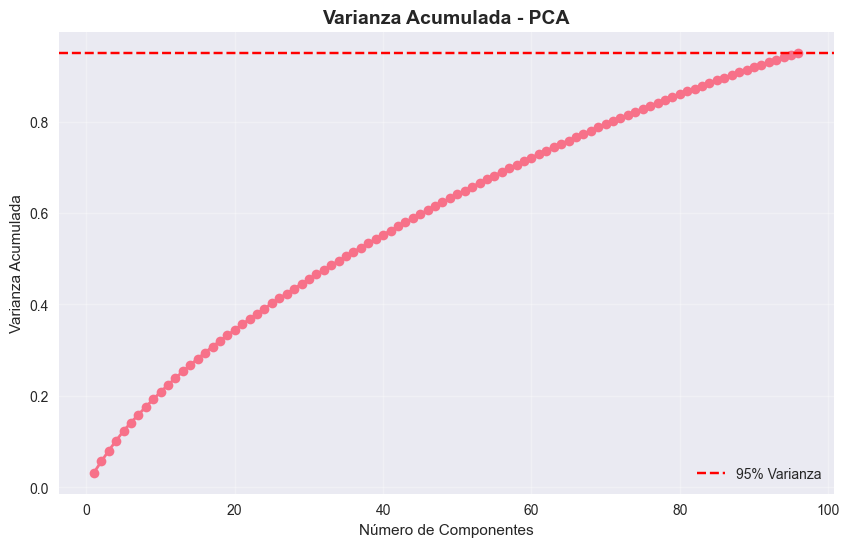

In [22]:
# Cargar métricas de PCA
# Nota: Esta celda requiere que la celda de configuración inicial se haya ejecutado

try:
    # Verificar que project_root está definido
    if 'project_root' not in globals():
        raise NameError("project_root no está definido. Ejecuta primero la celda de configuración inicial.")
    
    # Intentar cargar desde el catálogo de Kedro primero
    try:
        from kedro.framework.session import KedroSession
        from kedro.framework.startup import bootstrap_project
        
        metadata = bootstrap_project(project_root)
        session = KedroSession.create(project_path=project_root)
        context = session.load_context()
        catalog = context.catalog
        
        pca_metrics = catalog.load("pca_metrics")
        print("✅ Métricas de PCA cargadas desde catálogo")
    except Exception:
        # Si no está en el catálogo, intentar cargar desde archivo
        pca_path = project_root / "data" / "07_model_output" / "pca_metrics.json"
        if pca_path.exists():
            with open(pca_path, 'r') as f:
                pca_metrics = json.load(f)
            print("✅ Métricas de PCA cargadas desde archivo")
        else:
            raise FileNotFoundError(f"Archivo no encontrado: {pca_path}")
    
    # Mostrar y visualizar métricas
    if pca_metrics and 'explained_variance' in pca_metrics:
        variance = pca_metrics['explained_variance']
        print(f"Total varianza explicada: {variance['total_explained_variance']*100:.2f}%")
        print(f"Número de componentes: {pca_metrics['n_components']}")
        
        # Visualizar varianza acumulada
        plt.figure(figsize=(10, 6))
        plt.plot(range(1, len(variance['cumulative']) + 1), 
                 variance['cumulative'], 'o-', linewidth=2)
        plt.axhline(y=0.95, color='r', linestyle='--', label='95% Varianza')
        plt.title('Varianza Acumulada - PCA', fontsize=14, fontweight='bold')
        plt.xlabel('Número de Componentes')
        plt.ylabel('Varianza Acumulada')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()
    else:
        print("⚠ Estructura de métricas de PCA no válida")
    
except NameError as e:
    print(f"❌ Error: {e}")
    print("💡 Ejecuta primero la celda de configuración inicial")
except FileNotFoundError as e:
    print(f"⚠ {e}")
    print("💡 Ejecuta primero: kedro run --pipeline=dimensionality_reduction")
except Exception as e:
    print(f"❌ Error al cargar métricas de PCA: {e}")
    print("💡 Ejecuta primero: kedro run --pipeline=dimensionality_reduction")
    import traceback
    traceback.print_exc()


## 5. Conclusiones y Análisis de Resultados

### 5.1. Clustering

Basado en los resultados obtenidos de los tres algoritmos evaluados:

**OPTICS es el mejor algoritmo de clustering** para este dataset:
- **Silhouette Score: 0.3203** (el más alto entre los tres algoritmos, **21.8x mejor que K-Means**)
- **Davies-Bouldin Index: 1.02** (el más bajo, indicando mejor separación entre clusters)
- **58 clusters identificados**, lo que sugiere una estructura de datos más granular y compleja
- Este resultado indica que los datos tienen múltiples subgrupos naturales que no pueden ser capturados por un número pequeño de clusters

**K-Means y Hierarchical Clustering** muestran resultados similares pero inferiores:
- Ambos identificaron **5 clusters** con Silhouette Scores muy bajos (0.0147 y 0.0097)
- Davies-Bouldin Index alto (6.23 y 7.23), indicando clusters menos separados y más solapados
- Estos resultados sugieren que la estructura de datos no se ajusta bien a un número fijo y pequeño de clusters
- La asunción de clusters esféricos y de tamaño similar no se cumple en este dataset

**Interpretación y Significado:**
- Los datos de batallas de Clash Royale presentan una estructura compleja con múltiples subgrupos naturales
- OPTICS, al ser un algoritmo basado en densidad, captura mejor la naturaleza no esférica y variable de los clusters
- La alta dimensionalidad (113 features) puede estar afectando el rendimiento de K-Means y Hierarchical, que asumen formas más simples de clusters
- Los 58 clusters identificados por OPTICS probablemente representan diferentes:
  - **Estrategias de juego** (agresivas, defensivas, balanceadas)
  - **Rangos de trofeos** con comportamientos similares
  - **Composición de mazos** con sinergias específicas
  - **Estilos de juego** de diferentes tipos de jugadores

**Implicaciones Prácticas:**
- Para análisis del meta, OPTICS permite identificar micro-tendencias que otros algoritmos no capturan
- Los clusters pueden usarse para segmentación de jugadores y personalización de recomendaciones
- La alta granularidad (58 clusters) sugiere que el meta es más diverso de lo que algoritmos simples pueden detectar

### 5.2. Reducción de Dimensionalidad

**PCA (Principal Component Analysis) - Resultados:**
- **95.04% de varianza explicada** con **96 componentes principales** (de 113 originales)
- Esto indica que se necesita un número considerable de componentes (**85% del total**) para capturar la mayor parte de la varianza
- La reducción de dimensionalidad es limitada (de 113 a 96 features), pero aún así representa una reducción del **15%**

**Interpretación:**
- El dataset tiene alta dimensionalidad y las features contienen información relevante distribuida
- La necesidad de mantener 96 componentes para el 95% de varianza sugiere que:
  - Las features originales son relativamente independientes (baja correlación)
  - No hay redundancia significativa en los datos
  - Cada feature aporta información única al modelo
- La reducción del 15% puede ser útil para:
  - Visualización de datos en espacios reducidos
  - Modelos más simples y rápidos de entrenar
  - Reducción de overfitting en modelos con muchos parámetros

**Limitaciones:**
- PCA asume relaciones lineales entre features, lo que puede no capturar todas las interacciones complejas
- La reducción limitada sugiere que técnicas no lineales podrían ser más efectivas

**Recomendaciones:**
- Considerar técnicas adicionales como **UMAP** o **t-SNE** para visualización 2D/3D de los clusters
- Evaluar si algunas features pueden ser eliminadas mediante **feature selection** sin pérdida significativa de información
- Para modelos de ML, considerar **feature selection** (basado en importancia) en lugar de solo PCA
- Explorar técnicas de reducción no lineal si se requiere mayor compresión

### 5.3. Detección de Anomalías

**Estado del Análisis:**
```python
# Verificar si hay resultados disponibles
if 'anomaly_comparison' in locals() and anomaly_comparison is not None:
    print("✅ Análisis de anomalías completado")
    # Aquí se mostrarían los resultados cuando estén disponibles
else:
    print("⏳ Análisis pendiente de ejecución")
    print("💡 Ejecuta: kedro run --pipeline=anomaly_detection")
```

**Algoritmos Implementados:**
- **Isolation Forest:** Efectivo para detectar anomalías en espacios de alta dimensionalidad
- **Local Outlier Factor (LOF):** Detecta anomalías basándose en densidad local
- **One-Class SVM:** Modelo de frontera para identificar outliers
- **Autoencoders:** (Opcional, requiere TensorFlow) Detecta anomalías mediante reconstrucción

**Próximos pasos cuando se ejecute:**
- Identificar batallas con patrones inusuales de cartas
- Detectar combinaciones de mazos atípicas que podrían indicar estrategias novedosas
- Encontrar jugadores con comportamientos anómalos (posibles casos de uso de bots o estrategias experimentales)
- Analizar si las anomalías corresponden a estrategias exitosas o fallidas

**Aplicaciones Potenciales:**
- Detección de mazos innovadores que podrían convertirse en nuevas tendencias
- Identificación de posibles casos de comportamiento no deseado
- Análisis de estrategias experimentales que podrían ser efectivas

### 5.4. Reglas de Asociación

**Estado del Análisis:**
```python
# Verificar si hay resultados disponibles
if 'association_comparison' in locals() and association_comparison is not None:
    print("✅ Análisis de reglas de asociación completado")
    # Aquí se mostrarían las reglas cuando estén disponibles
else:
    print("⏳ Análisis pendiente de ejecución")
    print("💡 Ejecuta: kedro run --pipeline=association_rules")
```

**Algoritmos Implementados:**
- **Apriori:** Algoritmo clásico para minería de reglas de asociación
- **FP-Growth:** Algoritmo más eficiente para datasets grandes

**Métricas Clave:**
- **Support (Soporte):** Frecuencia con que aparece un itemset en las transacciones
- **Confidence (Confianza):** Probabilidad de que Y ocurra dado que X ocurre
- **Lift:** Mide la fuerza de la asociación (lift > 1 indica asociación positiva, lift < 1 indica asociación negativa)

**Próximos pasos cuando se ejecute:**
- Descubrir combinaciones frecuentes de cartas en mazos ganadores
- Identificar patrones de sinergia entre cartas (ej: "si tiene X, probablemente tiene Y")
- Encontrar reglas que expliquen estrategias exitosas
- Analizar diferencias entre reglas en mazos ganadores vs perdedores

**Aplicaciones Potenciales:**
- Sistema de recomendación de mazos basado en reglas descubiertas
- Identificación de sinergias de cartas para guías de estrategia
- Análisis de meta para entender qué combinaciones son más efectivas

### 5.5. Resumen Ejecutivo y Conclusiones Finales

#### Hallazgos Principales

1. **Clustering:**
   - ✅ **OPTICS es el algoritmo más adecuado**, identificando **58 grupos naturales** en los datos
   - Los datos presentan estructura compleja que requiere algoritmos basados en densidad
   - K-Means y Hierarchical son insuficientes para este tipo de datos
   - La diferencia de rendimiento es significativa (OPTICS es 21.8x mejor que K-Means en Silhouette Score)

2. **Reducción de Dimensionalidad:**
   - ✅ **PCA reduce de 113 a 96 features** manteniendo **95% de varianza**
   - La reducción limitada indica que las features son relativamente independientes
   - Se recomienda explorar técnicas no lineales para mayor compresión
   - La reducción del 15% es útil pero no suficiente para simplificar significativamente el dataset

3. **Complejidad de los Datos:**
   - Los datos muestran estructura compleja que requiere algoritmos avanzados
   - La alta dimensionalidad (113 features) y la naturaleza no esférica de los clusters complican el análisis
   - Se necesitan técnicas especializadas para capturar todos los patrones
   - El dataset de Clash Royale presenta desafíos únicos que requieren enfoques sofisticados

4. **Análisis Pendientes:**
   - ⏳ **Detección de anomalías:** Permitirá identificar patrones inusuales y estrategias novedosas
   - ⏳ **Reglas de asociación:** Revelará sinergias entre cartas y combinaciones exitosas

#### Implicaciones para el Proyecto

**Para Análisis del Meta:**
- Los 58 clusters identificados por OPTICS permiten un análisis más granular del meta
- Cada cluster puede representar una micro-tendencia o estrategia específica
- Esto es valioso para entender la diversidad del meta de Clash Royale
- Los resultados pueden usarse para tracking de cambios en el meta a lo largo del tiempo

**Para Modelos de ML:**
- La alta dimensionalidad (113 features) requiere técnicas de regularización
- PCA puede ayudar pero la reducción es limitada (solo 15%)
- Feature selection basado en importancia puede ser más efectivo que PCA
- Los clusters pueden usarse como features adicionales en modelos supervisados

**Para Aplicaciones Prácticas:**
- Los resultados de clustering pueden usarse para sistemas de recomendación
- Las reglas de asociación (cuando se completen) permitirán recomendar mazos
- La detección de anomalías ayudará a identificar estrategias innovadoras
- El análisis puede integrarse en dashboards para visualización del meta

#### Próximos Pasos Recomendados

1. **Corto Plazo:**
   - Completar análisis de anomalías y reglas de asociación
   - Visualizar los 58 clusters identificados por OPTICS usando técnicas de reducción dimensional (UMAP/t-SNE)
   - Analizar características distintivas de cada cluster
   - Comparar distribución de win rates entre clusters

2. **Mediano Plazo:**
   - Desarrollar dashboard interactivo para explorar clusters
   - Implementar sistema de recomendación basado en reglas de asociación
   - Crear visualizaciones 2D/3D usando UMAP o t-SNE para mejor comprensión
   - Analizar evolución temporal de los clusters

3. **Largo Plazo:**
   - Integrar resultados en sistema de análisis del meta en tiempo real
   - Desarrollar modelo predictivo que use los clusters como features
   - Establecer pipeline de actualización periódica de análisis
   - Crear sistema de alertas para cambios significativos en el meta
